In [1]:
import torch

# IOU

In [2]:
def iou(box1, box2):
    b1x1, b1y1, b1x2, b1y2 = box1
    b2x1, b2y1, b2x2, b2y2 = box2

    area1 = (b1x2 - b1x1) * (b1y2 - b1y1)
    area2 = (b2x2 - b2x1) * (b2y2 - b2y1)

    x_left = torch.max(b2x1, b1x1)
    y_top = torch.max(b1y1, b2y1)
    x_right = torch.min(b1x2, b2x2)
    y_bottom = torch.min(b1y2, b2y2)

    if x_right < x_left or y_bottom < y_top:
        return torch.tensor(0, dtype=torch.float)

    w = x_right - x_left
    h = y_bottom - y_top

    inter = w*h
    union = area1 + area2 - inter

    iou = inter / union
    return iou

In [ ]:
def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, torch.newaxis, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, torch.newaxis, 2:], boxes2[:, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]
    union = area1[:, torch.newaxis] + area2 - inter

    iou = inter / union
    return iou

# NMS

In [1]:
import torch
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from utils.nms import non_max_supression
from utils.convert_box import xyxy2xywh
from PIL import Image

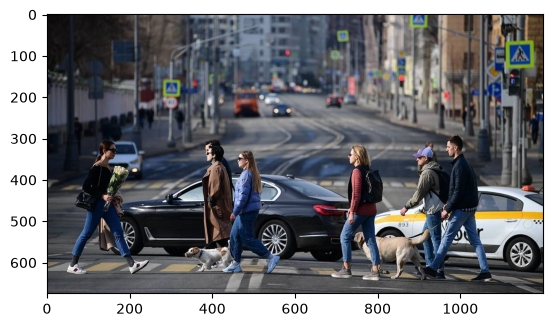

In [2]:
img = Image.open("images/000011.jpg").convert("RGB")
pred = torch.load("pred3.pt")

plt.imshow(img)

In [3]:
print(pred.shape)

torch.Size([1, 84, 5040])


In [4]:
pr = pred.transpose(-1, -2)
print("pr: ", pr.shape)

all_boxes = pr[..., :4].squeeze()
print(f"boxes: {all_boxes.shape}")

candidates = pr[..., 4:].amax(dim=2) > 0.25
print(f"candidates: {candidates.shape}, {candidates.dtype}")

cand_boxes = all_boxes[candidates[0]]
print(f"cand_boxes {cand_boxes.shape}")

pr:  torch.Size([1, 5040, 84])
boxes: torch.Size([5040, 4])
candidates: torch.Size([1, 5040]), torch.bool
cand_boxes torch.Size([136, 4])


In [5]:
def get_rect(box, color= "r"):
    return Rectangle(
        (box[0]-box[2]/2, box[1]-box[3]/2),
        box[2],
        box[3],
        linewidth=1,
        edgecolor=color,
        facecolor="none"
    )

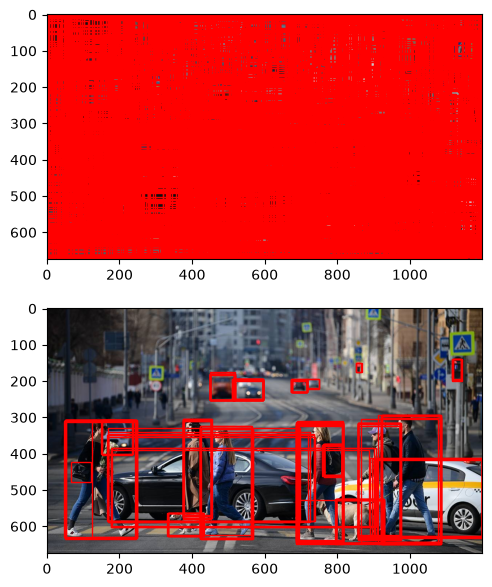

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1)

fig.set_size_inches(12, 7)

ax1.imshow(img)
ax2.imshow(img)

for box in all_boxes:
    rect = get_rect(box)
    ax1.add_patch(rect)

for box in cand_boxes:
    rect = get_rect(box)
    ax2.add_patch(rect)

    

In [7]:
best_boxes_nms = non_max_supression(pred)[0]
print(f"non_max_supression: {best_boxes_nms.shape}")

best_boxes = xyxy2xywh(best_boxes_nms[:, :4])
print(f"best_boxes: {best_boxes.shape}")

non_max_supression: torch.Size([20, 6])
best_boxes: torch.Size([20, 4])


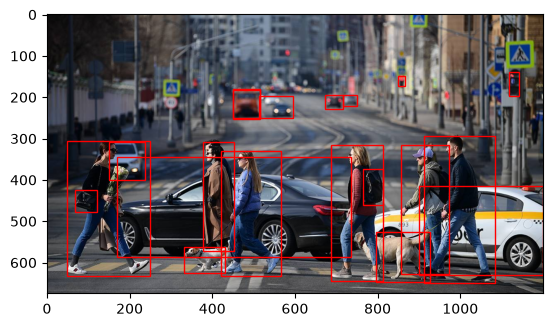

In [8]:
fig, ax = plt.subplots()

ax.imshow(img)

for box in best_boxes:
    rect = get_rect(box)
    ax.add_patch(rect)

